In [2]:
import torch
import torch.nn as nn
import timm
import bitsandbytes as bnb
import time
from datasets import load_dataset
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from tqdm import tqdm

# --- Configuration ---
DATA_FILES = "./data/validation-*.parquet" 
BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_dataloaders():
    print(f"Loading dataset from {DATA_FILES}...")
    dataset = load_dataset("parquet", data_files=DATA_FILES, split="train")
    
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    def preprocess(examples):
        images = [val_transform(img.convert('RGB')) for img in examples['image']]
        return {'image': images, 'label': examples['label']}

    dataset = dataset.with_transform(preprocess)
    
    # --- Project Proposal Requirement: 1k Calibration Subset ---
    # We split the 50,000 images: 1,000 for calibration and 49,000 for evaluation
    calib_indices = list(range(1000))
    eval_indices = list(range(1000, len(dataset)))
    
    calib_dataset = Subset(dataset, calib_indices)
    eval_dataset = Subset(dataset, eval_indices)
    
    calib_loader = DataLoader(calib_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
    eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
    
    return calib_loader, eval_loader

def replace_linear_with_bnb(module, quant_type="int8"):
    """
    Recursively replaces standard nn.Linear layers with bitsandbytes quantized layers.
    This physically shrinks the weights in VRAM.
    """
    for name, child in module.named_children():
        if isinstance(child, nn.Linear):
            has_bias = child.bias is not None
            if quant_type == "int8":
                # INT8 Quantization (with dynamic outlier thresholding)
                quant_layer = bnb.nn.Linear8bitLt(
                    child.in_features, child.out_features, bias=has_bias, has_fp16_weights=False, threshold=6.0
                )
            elif quant_type == "int4":
                # INT4 NormalFloat Quantization (Industry standard for modern ML)
                quant_layer = bnb.nn.Linear4bit(
                    child.in_features, child.out_features, bias=has_bias, quant_type="nf4"
                )
            
            # Transfer the weights into the new quantized layer
            quant_layer.weight.data = child.weight.data.clone()
            if has_bias:
                quant_layer.bias.data = child.bias.data.clone()
                
            # Move to GPU to trigger the internal C++ compression
            setattr(module, name, quant_layer.to(DEVICE))
        else:
            # Continue down the module tree
            replace_linear_with_bnb(child, quant_type)

def evaluate_model(model, eval_loader, precision_name):
    model.eval()
    correct = 0
    total = 0
    timings = []
    
    # Reset GPU memory stats to measure the exact footprint
    torch.cuda.reset_peak_memory_stats()
    
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for i, batch in enumerate(tqdm(eval_loader, desc=f"Evaluating {precision_name}")):
            inputs = batch['image'].to(DEVICE)
            targets = batch['label'].to(DEVICE)

            if i > 5:
                starter.record()
                    
            outputs = model(inputs)
            
            if i > 5:
                ender.record()
                torch.cuda.synchronize()
                timings.append(starter.elapsed_time(ender))

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    top1_acc = 100. * correct / total
    avg_latency_ms = sum(timings) / len(timings) if timings else 0 
    peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 * 1024)
    
    return top1_acc, avg_latency_ms, peak_memory_mb

def main():
    calib_loader, eval_loader = get_dataloaders()
    results = {}

    precisions = ["FP32 (Baseline)", "INT8", "INT4"]
    
    for precision in precisions:
        print(f"\n{'='*50}")
        print(f"Testing Precision: {precision}")
        print(f"{'='*50}")
        
        # Load a fresh, uncompressed model for each test so we don't double-compress
        model = timm.create_model('vit_small_patch16_224', pretrained=True).to(DEVICE)
        
        # Apply Quantization
        if precision == "INT8":
            print("Applying INT8 Compression...")
            replace_linear_with_bnb(model, quant_type="int8")
        elif precision == "INT4":
            print("Applying INT4 Compression...")
            replace_linear_with_bnb(model, quant_type="int4")
            
        # Calibration / Warmup Phase
        # For INT8, this initializes the dynamic outlier thresholds.
        # For all models, it warms up the GPU kernels for accurate timing.
        print("Running 1k Calibration/Warmup Subset...")
        with torch.no_grad():
            for batch in tqdm(calib_loader, desc="Calibrating", leave=False):
                inputs = batch['image'].to(DEVICE)
                _ = model(inputs) 
                
        # Evaluation Phase (Using the remaining 49k images)
        acc, lat, mem = evaluate_model(model, eval_loader, precision)
        results[precision] = {"Accuracy": acc, "Latency (ms)": lat, "Memory (MB)": mem}

    # --- Print Final Trade-off Matrix ---
    print(f"\n{'='*65}")
    print(f"{'Quantization Trade-off Matrix (Standard ViT)':^65}")
    print(f"{'='*65}")
    print(f"{'Precision':<18} | {'Accuracy (%)':<12} | {'Latency (ms)':<12} | {'Peak VRAM (MB)':<14}")
    print("-" * 65)
    for p, metrics in results.items():
        print(f"{p:<18} | {metrics['Accuracy']:>10.2f} % | {metrics['Latency (ms)']:>10.2f} ms | {metrics['Memory (MB)']:>10.2f} MB")
        
if __name__ == "__main__":
    main()

Loading dataset from ./data/validation-*.parquet...

Testing Precision: FP32 (Baseline)
Running 1k Calibration/Warmup Subset...


Evaluating FP32 (Baseline): 100%|██████████| 766/766 [02:37<00:00,  4.85it/s]



Testing Precision: INT8
Applying INT8 Compression...
Running 1k Calibration/Warmup Subset...


Calibrating:   0%|          | 0/16 [00:00<?, ?it/s]/home/mohnish/miniconda3/envs/d2_compression/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
Evaluating INT8: 100%|██████████| 766/766 [02:20<00:00,  5.46it/s]



Testing Precision: INT4


/home/mohnish/miniconda3/envs/d2_compression/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Applying INT4 Compression...
Running 1k Calibration/Warmup Subset...


Evaluating INT4: 100%|██████████| 766/766 [01:51<00:00,  6.87it/s]


          Quantization Trade-off Matrix (Standard ViT)           
Precision          | Accuracy (%) | Latency (ms) | Peak VRAM (MB)
-----------------------------------------------------------------
FP32 (Baseline)    |      74.59 % |     196.29 ms |     401.12 MB
INT8               |      74.59 % |     178.55 ms |     399.83 MB
INT4               |      71.14 % |     138.34 ms |     329.44 MB



[Success] Graph successfully saved as 'quantization_metrics.png'!


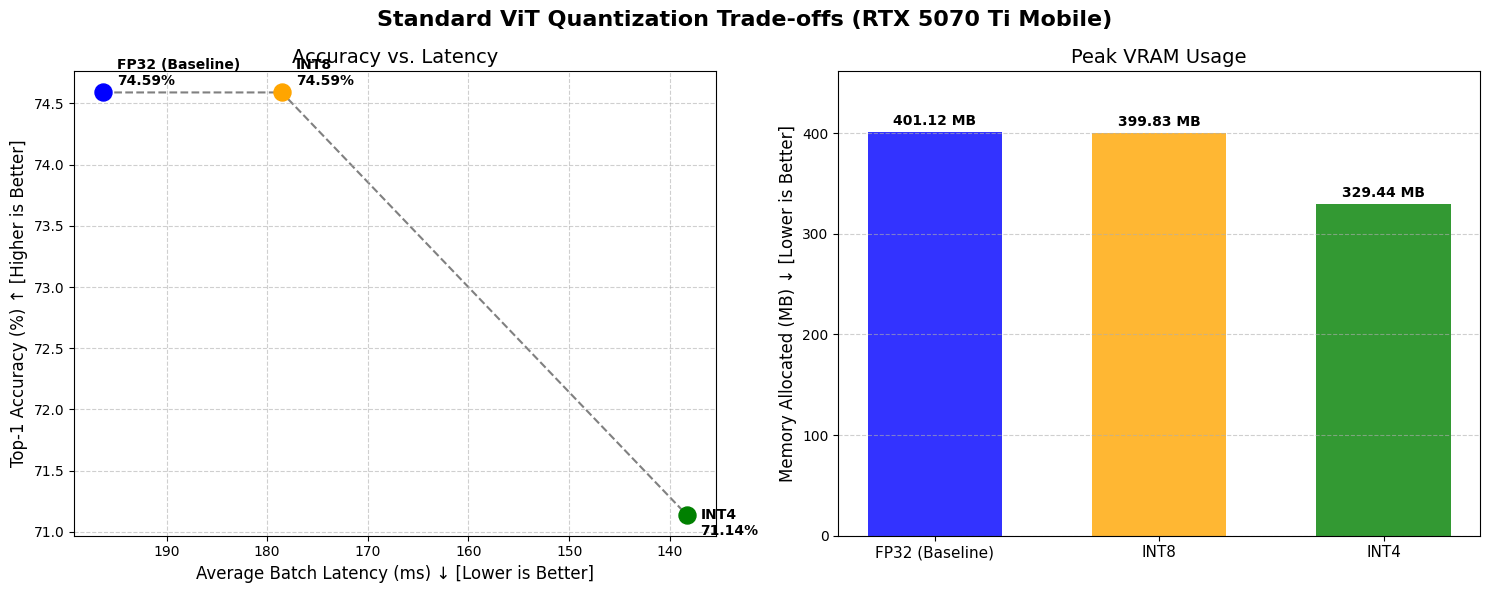

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_quantization_results():
    # --- Your RTX 5070 Ti Mobile Data ---
    precisions = ['FP32 (Baseline)', 'INT8', 'INT4']
    accuracies = [74.59, 74.59, 71.14]
    latencies = [196.29, 178.55, 138.34]
    vram = [401.12, 399.83, 329.44]

    # --- Setup the Figure ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Standard ViT Quantization Trade-offs (RTX 5070 Ti Mobile)', fontsize=16, fontweight='bold')

    # ==========================================
    # Plot 1: Accuracy vs. Latency Pareto Curve
    # ==========================================
    colors = ['blue', 'orange', 'green']
    
    # Plot the line connecting the points
    ax1.plot(latencies, accuracies, linestyle='--', color='gray', zorder=1)
    
    # Plot the individual points
    for i in range(len(precisions)):
        ax1.scatter(latencies[i], accuracies[i], color=colors[i], s=150, zorder=2, label=precisions[i])
        
        # Add text labels next to the dots
        ax1.annotate(
            f"{precisions[i]}\n{accuracies[i]}%", 
            (latencies[i], accuracies[i]),
            xytext=(10, -15) if i == 2 else (10, 5), # Shift the INT4 label down slightly so it doesn't overlap
            textcoords='offset points',
            fontweight='bold'
        )

    ax1.set_title("Accuracy vs. Latency", fontsize=14)
    ax1.set_xlabel("Average Batch Latency (ms) ↓ [Lower is Better]", fontsize=12)
    ax1.set_ylabel("Top-1 Accuracy (%) ↑ [Higher is Better]", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.invert_xaxis() # Standard Pareto orientation

    # ==========================================
    # Plot 2: Peak VRAM Footprint
    # ==========================================
    x_pos = np.arange(len(precisions))
    bars = ax2.bar(x_pos, vram, color=colors, alpha=0.8, width=0.6)

    # Add the text values on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(
            f'{height:.2f} MB',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom', fontweight='bold'
        )

    ax2.set_title("Peak VRAM Usage", fontsize=14)
    ax2.set_ylabel("Memory Allocated (MB) ↓ [Lower is Better]", fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(precisions, fontsize=11)
    ax2.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Give it some headroom so the text doesn't hit the top of the graph
    ax2.set_ylim(0, max(vram) * 1.15) 

    # --- Save and Show ---
    plt.tight_layout()
    output_filename = "quantization_metrics.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"\n[Success] Graph successfully saved as '{output_filename}'!")

if __name__ == "__main__":
    plot_quantization_results()